In [2]:
#Librerias a usar:

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

In [3]:
#definimos cosmo
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

# Constantes a utilizar
alpha = 0.7
redshifts = [1, 2, 3, 4, 5]


In [ ]:
# Cargar imagen
sfr_fits = fits.open("ngc6946Ha_I_Ha_ksb2004.fits")  
sfr_data = sfr_fits[0].data  


scaling_factor =  500 / np.sum(sfr_data)    #====================================
SFR_map = scaling_factor * sfr_data         #    Esto es la imagen original
SFR_map_log = np.log10(1 + SFR_map)         #====================================

In [5]:
# Conversión a luminosidad en 1.4 GHz y extraemos datos
lum_1_4GHz = sfr_data / 4.87e-29
lum_data = lum_1_4GHz[0].data 

# Valor de la luminosidad Total:
lum_total = np.sum(lum_1_4GHz)
print(f"Luminosidad total: {lum_total:.2e} erg/s/Hz")


Luminosidad total: 1.50e+33 erg/s/Hz


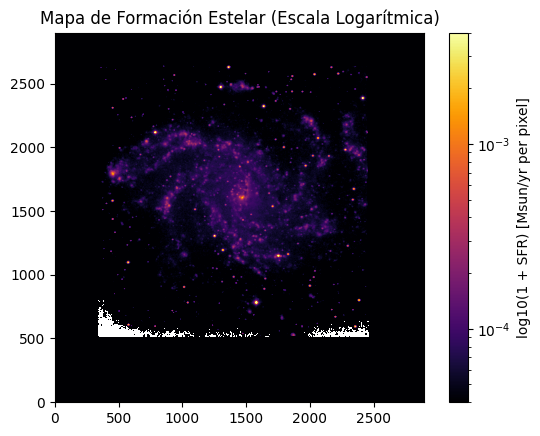

In [6]:
# Mostrar imagen orginal en SFR

plt.imshow(SFR_map_log, origin="lower", cmap="inferno", norm=LogNorm(vmin=4e-5 , vmax=4e-3))
plt.colorbar(label="log10(1 + SFR) [Msun/yr per pixel]")
plt.title("Mapa de Formación Estelar (Escala Logarítmica)")
plt.show()

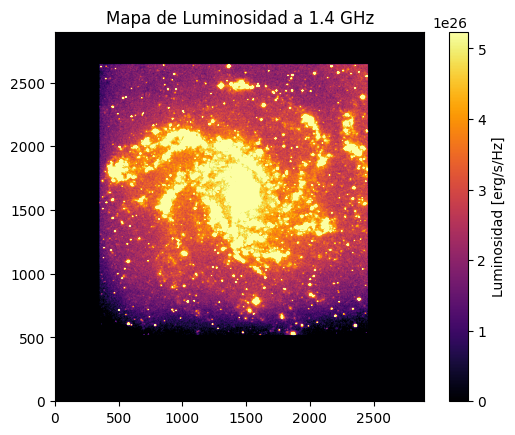

In [16]:
#Imagen convertida a Luminsidad

plt.imshow(lum_1_4GHz, origin="lower", cmap="inferno", norm=plt.Normalize(vmin=np.percentile(lum_1_4GHz, 5), vmax=np.percentile(lum_1_4GHz, 95)))
plt.colorbar(label="Luminosidad [erg/s/Hz]")
plt.title("Mapa de Luminosidad a 1.4 GHz")
plt.show()

In [8]:
# Convertir de luminosidad a densidad de flujo a 10 GHz
def luminosity_to_flux(lum_1_4GHz, z, alpha):

    D_L = cosmo.luminosity_distance(z).to('cm').value

    factor = (4 * np.pi * D_L**2) / ((1+z)**(1-alpha) * (1.4/10)**(-alpha))
    S_10GHz = lum_1_4GHz / factor

    return S_10GHz

In [10]:
#Valor de la distancia de luminosidad a z=4
D_l = cosmo.luminosity_distance(1.5).to('cm').value
print(f"Distancia de luminosidad a z=1.5: {D_l:.2e} cm")

# Sumamos los valores para obtener la densidad de flujo total
flujo_total = np.sum(luminosity_to_flux(lum_1_4GHz, 4, alpha))
print(f"Densidad de flujo total a 10 GHz: {flujo_total} erg/s/cm^2/Hz")

# Convertir de erg/s/cm^2/Hz a Jy
flujo_total_jy = flujo_total * 1e23
print(f"Densidad de flujo total a 10 GHz: {flujo_total_jy:.2e} Jy")


Distancia de luminosidad a z=1.5: 3.37e+28 cm
Densidad de flujo total a 10 GHz: 6.283568890598528e-26 erg/s/cm^2/Hz
Densidad de flujo total a 10 GHz: 6.28e-03 Jy


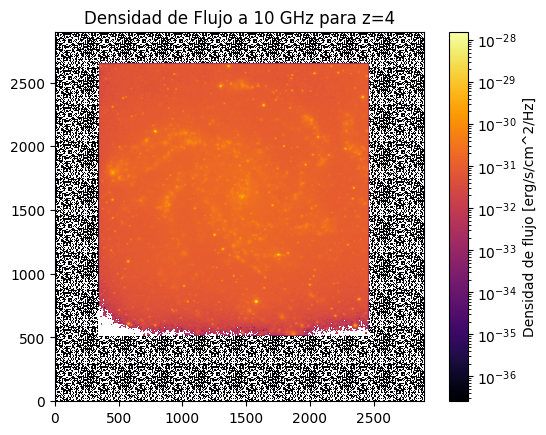

In [ ]:
#Le aplicamos el reescalamiento logaritmico a los nuevos datos
S_10GHz_map = luminosity_to_flux(lum_1_4GHz, 1.5, alpha)
S_10GHz_log = np.log10(1 + S_10GHz_map)

#Grafica con diferentes redshifts
plt.imshow(S_10GHz_map, origin='lower', cmap='inferno', norm=LogNorm(vmin=1e-5, vmax=1e-1))
plt.colorbar(label="Densidad de flujo [erg/s/cm^2/Hz]")
plt.title("Densidad de Flujo a 10 GHz para z=4")
plt.show()

In [ ]:
#Valores maximos 

max_value = np.max(S_10GHz_map)
print(f"Valor máximo de la densidad de flujo a 10 GHz: {max_value:.2e} erg/s/cm^2/Hz")

max_value_log = np.max(S_10GHz_log)
print(f"Valor máximo de la densidad de flujo a 10 GHz (log): {max_value_log:.2e} erg/s/cm^2/Hz")


#Valores minimos

min_value = np.min(S_10GHz_map)
print(f"Valor mínimo de la densidad de flujo a 10 GHz: {min_value:.2e} erg/s/cm^2/Hz")

min_value_log = np.min(S_10GHz_log)
print(f"Valor mínimo de la densidad de flujo a 10 GHz (log): {min_value_log:.2e} erg/s/cm^2/Hz")

Valor máximo de la densidad de flujo a 10 GHz: 1.57e-28 erg/s/cm^2/Hz
Valor máximo de la densidad de flujo a 10 GHz (log): 0.00e+00 erg/s/cm^2/Hz
Valor mínimo de la densidad de flujo a 10 GHz: -9.43e-32 erg/s/cm^2/Hz
Valor mínimo de la densidad de flujo a 10 GHz (log): 0.00e+00 erg/s/cm^2/Hz
